In [1]:
import os
import sys
current_dir = os.getcwd()
parent_dir = os.path.dirname(current_dir)
sys.path.insert(0, parent_dir)
# Set the parent directory as the current directory
os.chdir(parent_dir)

In [ ]:
import json
import re
import difflib
import numpy as np
from collections import Counter
from typing import List, Dict, Any, Optional

def normalize_text(text):
    """
    Normalize text for more robust matching:
    - Convert to lowercase
    - Remove extra whitespaces
    - Remove punctuation
    """
    if not text:
        return ""
        
    # Convert to lowercase
    text = text.lower()
    
    # Remove extra whitespaces
    text = re.sub(r'\s+', ' ', text).strip()
    
    # Remove punctuation (but keep some meaningful characters)
    text = re.sub(r'[^\w\s°-]', ' ', text)
    
    return text

def is_direct_phenotype(phenotype, clinical_text, threshold=0.85):
    """
    Determine if a phenotype is directly mentioned in the text, accounting for minor variations.
    
    Args:
        phenotype: The phenotype name to check
        clinical_text: The clinical note text
        threshold: Similarity threshold for considering direct mention (higher = stricter)
        
    Returns:
        Boolean indicating if the phenotype is directly mentioned
    """
    norm_phenotype = normalize_text(phenotype)
    norm_text = normalize_text(clinical_text)
    
    # Check for exact match first
    if norm_phenotype in norm_text:
        return True
    
    # Check individual words from the text 
    text_words = norm_text.split()
    
    # For single-word phenotypes
    if len(norm_phenotype.split()) == 1:
        for word in text_words:
            # Use character-level similarity for single words
            similarity = difflib.SequenceMatcher(None, norm_phenotype, word).ratio()
            if similarity >= threshold:
                return True
    
    # For multi-word phenotypes, check n-grams in the text
    phenotype_words = norm_phenotype.split()
    n = len(phenotype_words)
    
    for i in range(len(text_words) - n + 1):
        text_ngram = " ".join(text_words[i:i+n])
        
        # Check similarity of the entire phrase
        similarity = difflib.SequenceMatcher(None, norm_phenotype, text_ngram).ratio()
        if similarity >= threshold:
            return True
    
    # Check for medical term variations
    variations = generate_medical_variations(phenotype)
    for variation in variations:
        norm_variation = normalize_text(variation)
        if norm_variation in norm_text:
            return True
        
        # Also check fuzzy matching for variations
        for i in range(len(text_words) - len(norm_variation.split()) + 1):
            text_ngram = " ".join(text_words[i:i+len(norm_variation.split())])
            similarity = difflib.SequenceMatcher(None, norm_variation, text_ngram).ratio()
            if similarity >= threshold:
                return True
    
    # If we've reached here, it's not a direct phenotype
    return False

def generate_medical_variations(term):
    """Generate common variations of medical terms."""
    variations = []
    
    # Handle plural forms
    if not term.endswith('s'):
        variations.append(term + 's')  # Simple plural
    
    if term.endswith('y'):
        variations.append(term[:-1] + 'ies')  # y -> ies
    
    if term.endswith('us'):
        variations.append(term[:-2] + 'i')  # us -> i
    
    # Handle hyphenated vs non-hyphenated
    if '-' in term:
        variations.append(term.replace('-', ' '))
    if ' ' in term:
        variations.append(term.replace(' ', '-'))
    
    # Handle common abbreviations
    # This would need to be expanded for specific medical domains
    abbreviations = {
        'cardiomyopathy': 'CM',
        'myocardial infarction': 'MI',
        'congestive heart failure': 'CHF',
        'diabetes mellitus': 'DM',
        'hypertension': 'HTN',
        'chronic obstructive pulmonary disease': 'COPD'
    }
    
    if term.lower() in abbreviations:
        variations.append(abbreviations[term.lower()])
    
    # Check if term is an abbreviation and add the full form
    inv_abbreviations = {v.lower(): k for k, v in abbreviations.items()}
    if term.upper() in [k.upper() for k in inv_abbreviations.keys()]:
        variations.append(inv_abbreviations[term.lower()])
    
    return variations

def find_best_context(phenotype, clinical_text, window_size=150):
    """
    Find the most likely context where the implied phenotype might reside,
    using fuzzy matching and a sliding window approach.
    
    Args:
        phenotype: The implied phenotype to match
        clinical_text: The complete clinical note text
        window_size: Size of context window (characters)
        
    Returns:
        The best matching context snippet
    """
    norm_phenotype = normalize_text(phenotype)
    norm_text = normalize_text(clinical_text)
    
    # If exact match exists, extract the context around it
    if norm_phenotype in norm_text:
        # Find position of the match
        start_pos = norm_text.find(norm_phenotype)
        # Extract context window
        context_start = max(0, start_pos - window_size//2)
        context_end = min(len(norm_text), start_pos + len(norm_phenotype) + window_size//2)
        # Return the original text for this section
        window_start = len(normalize_text(clinical_text[:context_start]))
        window_end = len(normalize_text(clinical_text[:context_end]))
        return clinical_text[window_start:window_end].strip()
    
    # No exact match, try fuzzy matching with sliding windows
    best_score = 0
    best_context = ""
    
    # Create text windows with sentences to preserve logical units
    sentences = re.split(r'(?<=[.!?])\s+', clinical_text)
    current_window = ""
    
    for sentence in sentences:
        # If adding this sentence exceeds window size, evaluate current window
        if len(current_window + " " + sentence) > window_size * 2:
            norm_window = normalize_text(current_window)
            
            # Calculate similarity score
            words = norm_window.split()
            max_word_score = 0
            
            # Try matching with individual words and phrases
            for j in range(len(words)):
                for k in range(j+1, min(j+6, len(words)+1)):  # Try phrases up to 5 words
                    phrase = " ".join(words[j:k])
                    score = difflib.SequenceMatcher(None, norm_phenotype, phrase).ratio()
                    max_word_score = max(max_word_score, score)
            
            # Also try matching against the whole window
            window_score = difflib.SequenceMatcher(None, norm_phenotype, norm_window).ratio()
            score = max(max_word_score, window_score)
            
            if score > best_score:
                best_score = score
                best_context = current_window
            
            # Reset window, starting with the current sentence
            current_window = sentence
        else:
            # Add sentence to current window
            if current_window:
                current_window += " " + sentence
            else:
                current_window = sentence
    
    # Check the last window
    if current_window:
        norm_window = normalize_text(current_window)
        window_score = difflib.SequenceMatcher(None, norm_phenotype, norm_window).ratio()
        if window_score > best_score:
            best_score = window_score
            best_context = current_window
    
    # If we found a reasonably good match
    if best_score > 0.4:
        return best_context.strip()
    
    # Look for relevant medical terms in each sentence as a fallback
    # This helps find relevant context even with conceptual implications
    medical_terms = [
        "elevated", "increased", "decreased", "low", "high", "abnormal",
        "level", "count", "test", "positive", "negative", "detected",
        "diagnosis", "symptom", "sign", "finding", "disease", "disorder",
        "syndrome", "condition", "complication", "deficit", "dysfunction"
    ]
    
    best_term_count = 0
    best_term_context = ""
    
    for sentence in sentences:
        term_count = sum(1 for term in medical_terms if term in sentence.lower())
        if term_count > best_term_count:
            best_term_count = term_count
            best_term_context = sentence
    
    if best_term_context:
        return best_term_context.strip()
    
    # Ultimate fallback: Return first part of the text as context
    return clinical_text[:min(window_size, len(clinical_text))].strip()

def process_dataset(input_file_path, output_file_path):
    """
    Process dataset to create a new JSON structure with implied phenotypes, HPO codes and contexts.
    
    Args:
        input_file_path: Path to input JSON dataset
        output_file_path: Path to output JSON dataset
    """
    # Load the input dataset
    with open(input_file_path, 'r') as f:
        input_data = json.load(f)
    
    # Create output dataset
    output_data = {}
    
    # Process each document
    for doc_id, doc_data in input_data.items():
        # Get clinical text
        clinical_text = doc_data.get("clinical_text", "")
        if not clinical_text:
            continue
        
        # Get phenotypes
        phenotypes = doc_data.get("phenotypes", [])
        if not phenotypes and "verified_phenotypes" in doc_data:
            phenotypes = doc_data.get("verified_phenotypes", [])
        
        # Track all phenotypes for this document
        all_phenotypes = []
        implied_phenotypes_with_context = []
        direct_phenotypes = []
        
        for phenotype_item in phenotypes:
            # Handle different phenotype data structures
            if isinstance(phenotype_item, dict):
                # Extract phenotype name based on available fields
                phenotype_name = phenotype_item.get("phenotype", "")
                if not phenotype_name:
                    phenotype_name = phenotype_item.get("phenotype_name", "")
                
                # Extract HPO code
                hpo_code = phenotype_item.get("hp_id", "")
                if not hpo_code:
                    hpo_code = phenotype_item.get("HPO_Term", "")  # Alternative field name
                if not hpo_code:
                    hpo_code = phenotype_item.get("hpo_id", "")    # Another alternative
                if not hpo_code:
                    hpo_code = phenotype_item.get("hpo_term", "")  # Another alternative
                
                # Try to determine if it's implied using proper fuzzy matching
                status = phenotype_item.get("status", "")
                
                # If status is already specified, use it
                if status == "implied_phenotype":
                    is_implied = True
                elif status == "direct_phenotype":
                    is_implied = False
                else:
                    # Otherwise use our fuzzy matching logic
                    is_implied = not is_direct_phenotype(phenotype_name, clinical_text)
            
            elif isinstance(phenotype_item, str):
                phenotype_name = phenotype_item
                hpo_code = ""  # No HPO code available for string phenotypes
                # Use fuzzy matching to determine if implied
                is_implied = not is_direct_phenotype(phenotype_name, clinical_text)
            
            else:
                continue
            
            # Skip if no phenotype name
            if not phenotype_name:
                continue
                
            # Categorize as direct or implied
            phenotype_info = {
                "phenotype": phenotype_name,
                "hpo_code": hpo_code,
            }
            
            all_phenotypes.append(phenotype_info)
            
            if is_implied:
                # Find best context for implied phenotypes
                context = find_best_context(phenotype_name, clinical_text)
                
                # Add to implied phenotypes list
                implied_phenotypes_with_context.append({
                    "implied_phenotype": phenotype_name,
                    "hpo_code": hpo_code,
                    "context": context
                })
            else:
                # Track direct phenotypes
                direct_phenotypes.append(phenotype_info)
        
        # Add to output data
        output_data[doc_id] = {
            "text": clinical_text,
            "all_phenotypes": all_phenotypes,
            "direct_phenotypes": direct_phenotypes,
            "implied_phenotypes_with_context": implied_phenotypes_with_context
        }
    
    # Save the output dataset
    with open(output_file_path, 'w') as f:
        json.dump(output_data, f, indent=2)
    
    # Calculate statistics
    total_direct = sum(len(doc["direct_phenotypes"]) for doc in output_data.values())
    total_implied = sum(len(doc["implied_phenotypes_with_context"]) for doc in output_data.values())
    total_phenotypes = total_direct + total_implied
    
    print(f"Processed {len(input_data)} documents, saved {len(output_data)} to {output_file_path}")
    print(f"Found {total_phenotypes} total phenotypes")
    print(f"Direct phenotypes: {total_direct} ({total_direct/total_phenotypes*100:.1f}% of total)")
    print(f"Implied phenotypes: {total_implied} ({total_implied/total_phenotypes*100:.1f}% of total)")
    
    # Print statistics on HPO code availability
    with_hpo = 0
    without_hpo = 0
    for doc in output_data.values():
        for item in doc["implied_phenotypes_with_context"]:
            if item["hpo_code"]:
                with_hpo += 1
            else:
                without_hpo += 1
    
    if with_hpo + without_hpo > 0:
        print(f"Implied phenotypes with HPO codes: {with_hpo} ({with_hpo/(with_hpo+without_hpo)*100:.1f}%)")
        print(f"Implied phenotypes without HPO codes: {without_hpo} ({without_hpo/(with_hpo+without_hpo)*100:.1f}%)")
    
    return output_data

# Example usage for Jupyter notebook:
# Define your input and output paths

# Run the processing function
# output_data = process_dataset(input_file_path, output_file_path)


# Run the processing function
# output_data = process_dataset(input_file_path, output_file_path)

# Example usage for Jupyter notebook:
# Define your input and output paths

# hpo_data = read_json_file('data/dataset/mine_hpo.json')

input_file_path = 'data/dataset/mine_hpo.json'
output_file_path = "data/dataset/implied_phenotypes.json"

# Run the processing function
output_data = process_dataset(input_file_path, output_file_path)


Processed 116 documents, saved 116 to data/dataset/implied_phenotypes.json
Found 1813 total phenotypes
Direct phenotypes: 1320 (72.8% of total)
Implied phenotypes: 493 (27.2% of total)
Implied phenotypes with HPO codes: 493 (100.0%)
Implied phenotypes without HPO codes: 0 (0.0%)


Overall Performance Metrics:
Precision: 0.6258
Recall: 0.6779
F1 Score: 0.6508
True Positives: 1229
False Positives: 735
False Negatives: 584


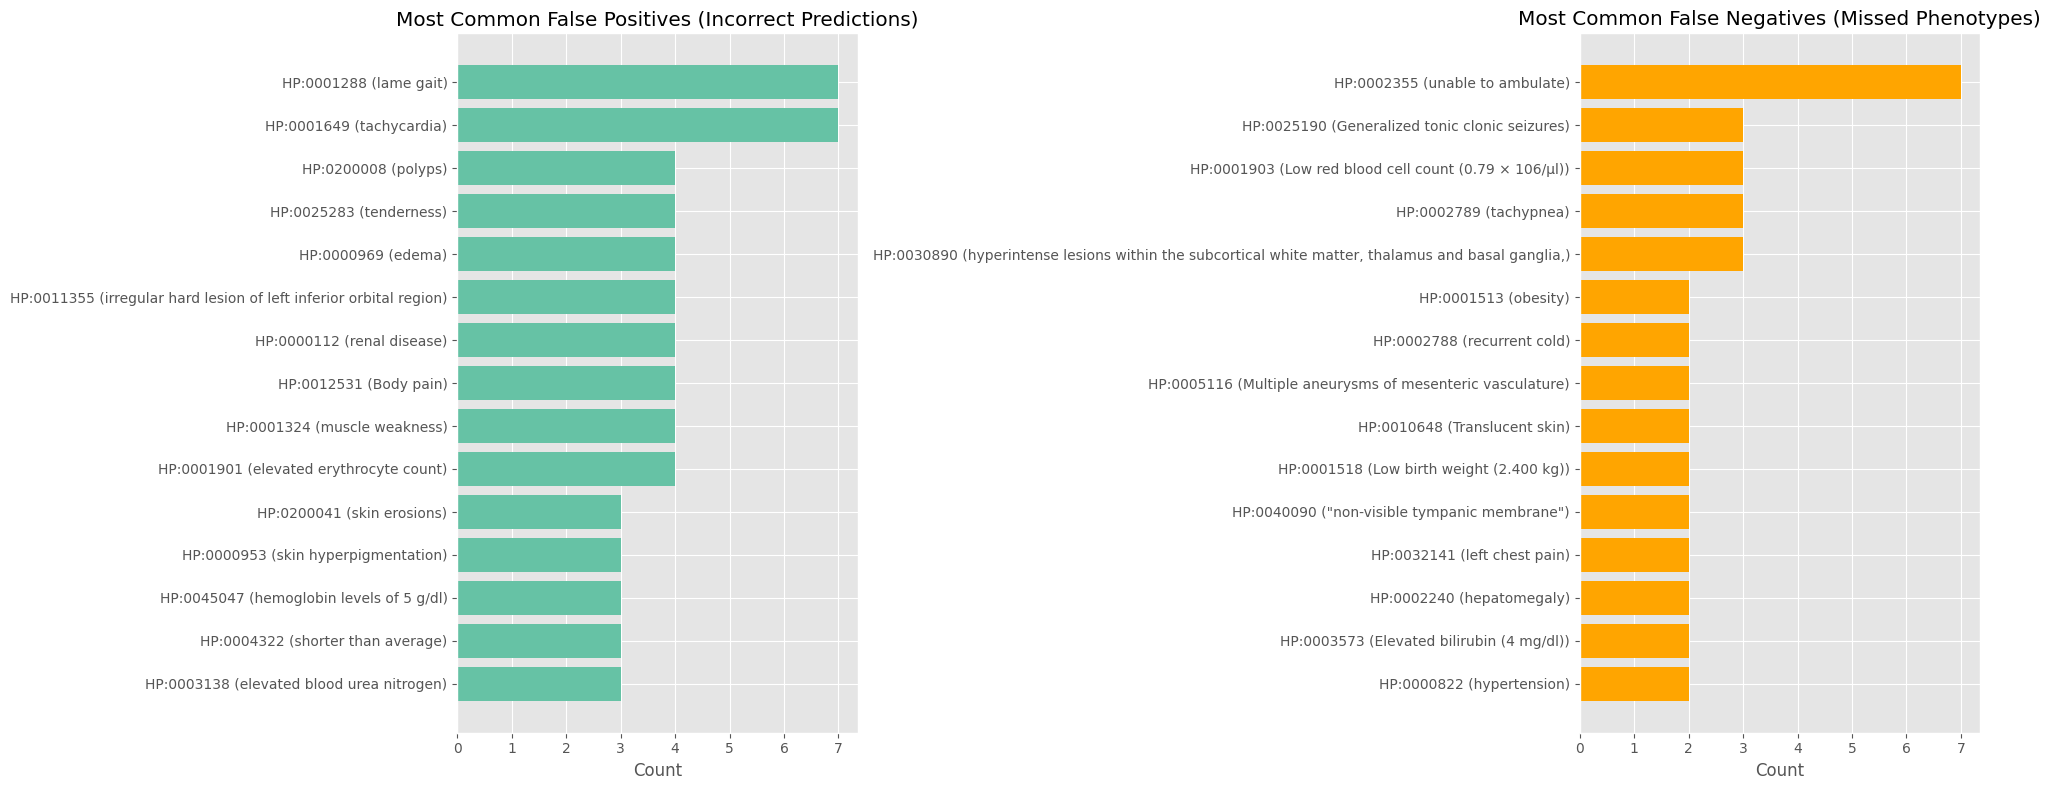

<Figure size 2000x800 with 0 Axes>


Error distribution visualization saved to 'data/figures/error_distribution.png'

Top 20 False Positives (Incorrect Predictions):


,HPO Code,Phenotype Name,Count
0,HP:0001288,lame gait,7
1,HP:0001649,tachycardia,7
2,HP:0200008,polyps,4
3,HP:0025283,tenderness,4
4,HP:0000969,edema,4
5,HP:0011355,irregular hard lesion of left inferior orbital...,4
6,HP:0000112,renal disease,4
7,HP:0012531,Body pain,4
8,HP:0001324,muscle weakness,4
9,HP:0001901,elevated erythrocyte count,4


Table saved to 'data/figures/top_false_positives.csv'


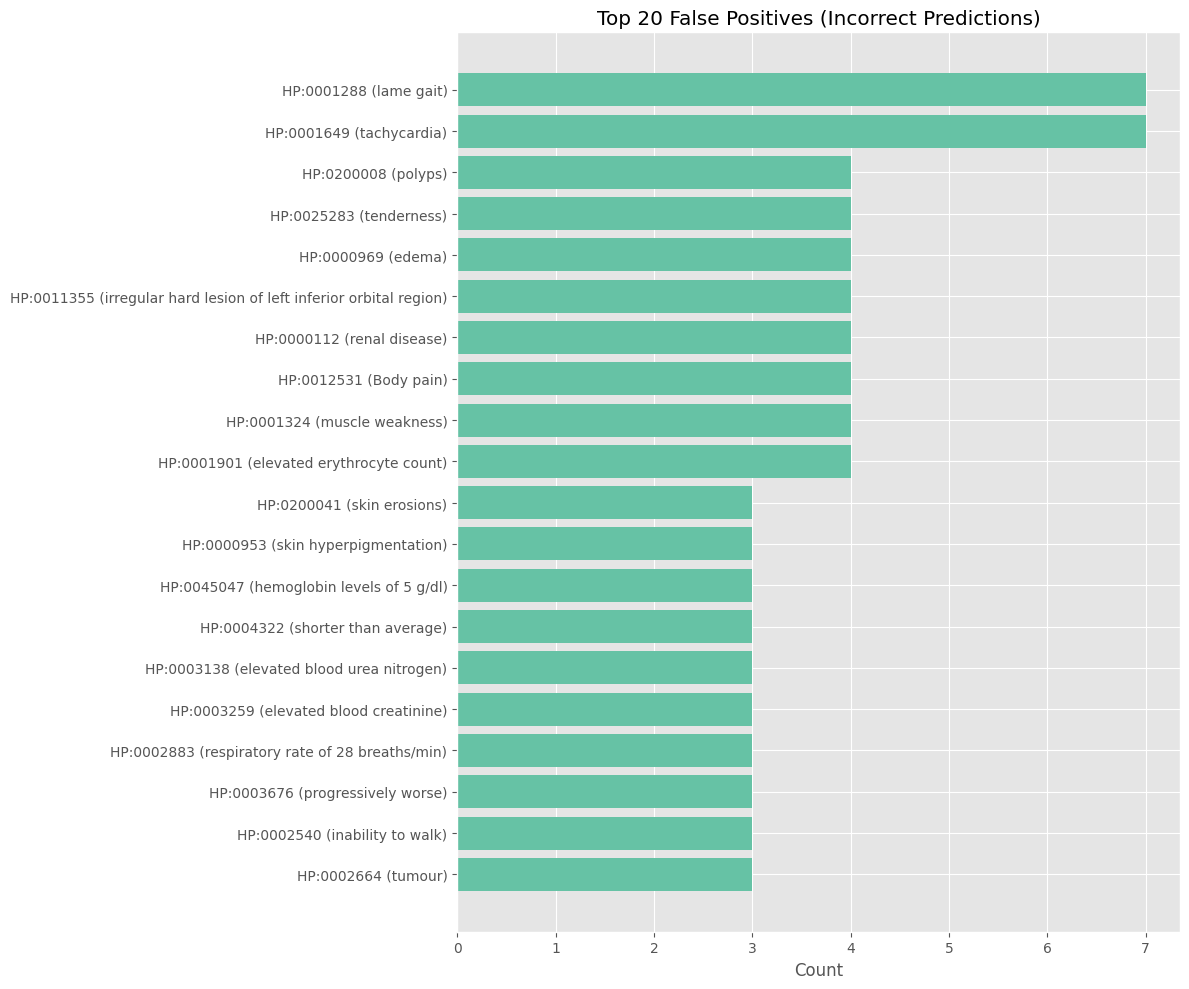


Top 20 False Negatives (Missed Phenotypes):


,HPO Code,Phenotype Name,Count
0,HP:0002355,unable to ambulate,7
1,HP:0025190,Generalized tonic clonic seizures,3
2,HP:0001903,Low red blood cell count (0.79 × 106/μl),3
3,HP:0002789,tachypnea,3
4,HP:0030890,hyperintense lesions within the subcortical wh...,3
5,HP:0001513,obesity,2
6,HP:0002788,recurrent cold,2
7,HP:0005116,Multiple aneurysms of mesenteric vasculature,2
8,HP:0010648,Translucent skin,2
9,HP:0001518,Low birth weight (2.400 kg),2


Table saved to 'data/figures/top_false_negatives.csv'


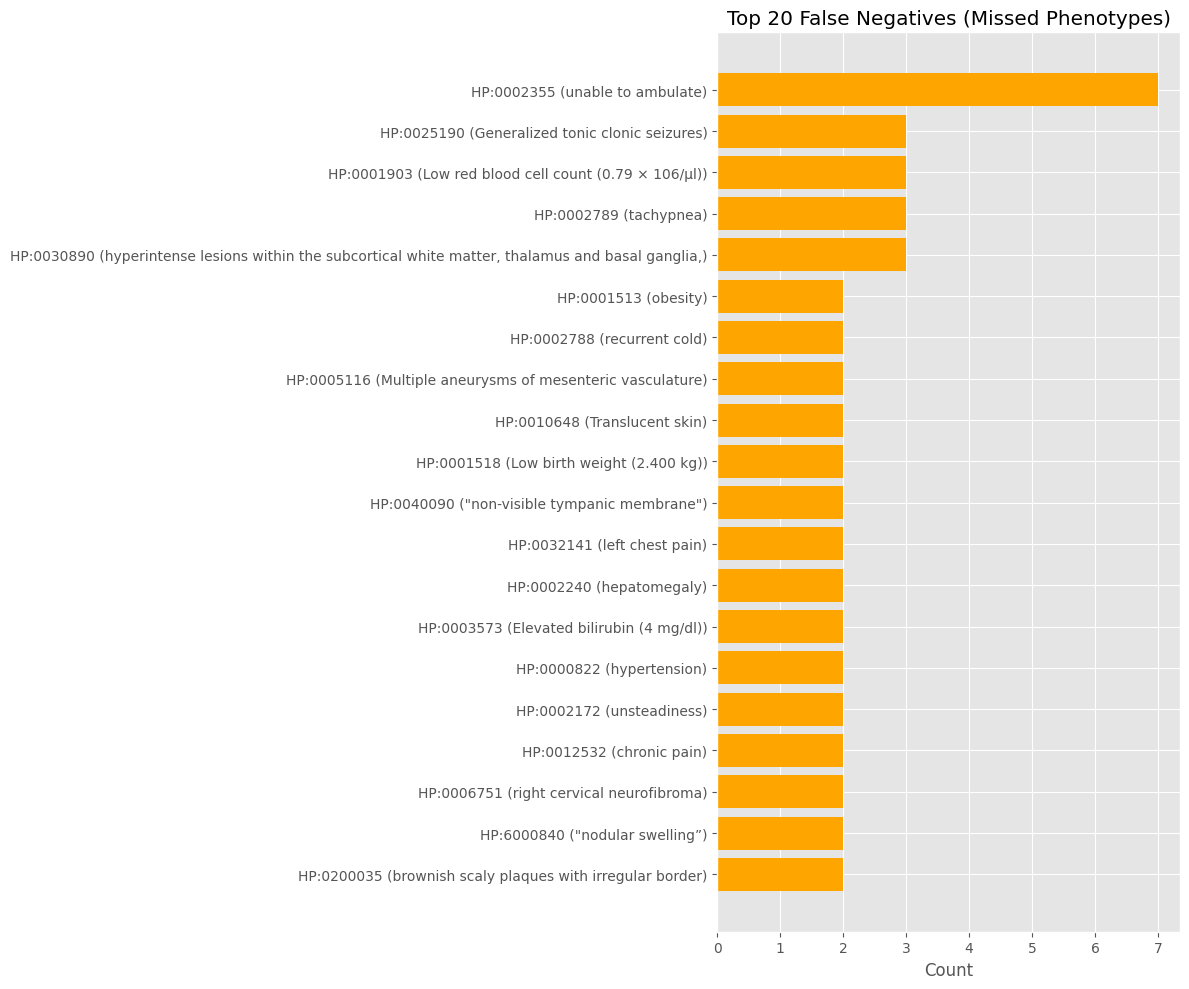

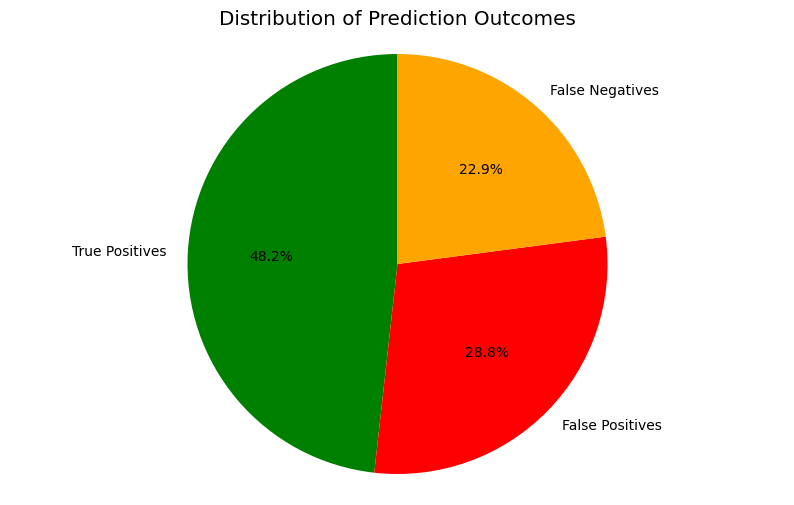


Analysis complete! All results and visualizations have been saved to the data/figures directory.


In [5]:
import json
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
from typing import Dict, List, Tuple, Any
from fuzzywuzzy import fuzz

# Set style for better visualization
plt.style.use('ggplot')
sns.set_palette("Set2")

def normalize_text(text: str) -> str:
    """Normalize text by converting to lowercase and removing extra whitespace."""
    if not isinstance(text, str):
        return ""
    return ' '.join(text.lower().split())

def load_data(predictions_file: str, ground_truth_file: str):
    """Load prediction and ground truth data."""
    with open(predictions_file, 'r') as f:
        predictions = json.load(f)
    
    with open(ground_truth_file, 'r') as f:
        ground_truth = json.load(f)
    
    # Handle nested structure with metadata and results keys
    if isinstance(predictions, dict) and "results" in predictions:
        predictions_data = predictions.get("results", {})
    else:
        predictions_data = predictions
    
    return predictions_data, ground_truth

def extract_predictions(predictions_data: Dict) -> Dict[str, List[str]]:
    """Extract HPO codes from the predictions data structure."""
    result = {}
    
    # Handle different possible formats
    if isinstance(predictions_data, dict):
        for case_id, case_data in predictions_data.items():
            hpo_codes = []
            
            # Check for different possible field names for phenotype lists
            phenotype_fields = ["matched_phenotypes", "verified_phenotypes"]
            for field in phenotype_fields:
                if field in case_data:
                    phenotype_list = case_data[field]
                    if isinstance(phenotype_list, list):
                        for item in phenotype_list:
                            if not isinstance(item, dict):
                                continue
                                
                            # Check for different possible field names for HPO codes
                            for code_field in ["HPO_Term", "hpo_term", "hpo_id", "hp_id"]:
                                if code_field in item:
                                    code = item[code_field]
                                    # Ensure code starts with HP:
                                    if code and isinstance(code, str) and code.startswith("HP:"):
                                        hpo_codes.append(code)
                                        break
            
            # Add non-empty lists to result
            if hpo_codes:
                result[str(case_id)] = hpo_codes
    
    return result

def extract_ground_truth(ground_truth_data: Dict) -> Dict[str, List[str]]:
    """Extract ground truth HPO codes from the ground truth data structure."""
    result = {}
    
    # Handle different possible formats
    if isinstance(ground_truth_data, dict):
        for case_id, case_data in ground_truth_data.items():
            hpo_codes = []
            
            # Try different possible field names
            for field in ["phenotypes", "ground_truth", "hpo_terms"]:
                if field in case_data:
                    field_data = case_data[field]
                    if isinstance(field_data, list):
                        for item in field_data:
                            # Check for different possible field names in nested dictionaries
                            if isinstance(item, dict):
                                for code_field in ["hpo_id", "HPO_Term", "hpo_code", "hp_id"]:
                                    if code_field in item:
                                        code = item[code_field]
                                        # Ensure code starts with HP:
                                        if code and isinstance(code, str) and code.startswith("HP:"):
                                            hpo_codes.append(code)
                                        break
                            elif isinstance(item, str) and item.startswith("HP:"):
                                # Direct HPO code string
                                hpo_codes.append(item)
            
            # Add non-empty lists to result
            if hpo_codes:
                result[str(case_id)] = hpo_codes
    
    return result

def extract_phenotype_names(data: Dict, is_ground_truth: bool = False) -> Dict[str, str]:
    """Extract HPO code to phenotype name mappings."""
    code_to_name = {}
    
    if isinstance(data, dict):
        for case_id, case_data in data.items():
            # Determine which fields to check based on whether it's ground truth or predictions
            if is_ground_truth:
                fields_to_check = ["phenotypes", "ground_truth", "hpo_terms"]
            else:
                fields_to_check = ["matched_phenotypes", "verified_phenotypes"]
                
            for field in fields_to_check:
                if field in case_data:
                    phenotype_list = case_data[field]
                    if isinstance(phenotype_list, list):
                        for item in phenotype_list:
                            if not isinstance(item, dict):
                                continue
                            
                            # Get phenotype name and code
                            phenotype_name = None
                            hpo_code = None
                            
                            # Check various possible field names for the phenotype name
                            for name_field in ["phenotype", "entity", "name", "phenotype_name", "text"]:
                                if name_field in item and item[name_field]:
                                    phenotype_name = item[name_field]
                                    break
                            
                            # Check various possible field names for the HPO code
                            for code_field in ["HPO_Term", "hpo_term", "hpo_id", "hp_id", "HPO_ID"]:
                                if code_field in item and item[code_field]:
                                    hpo_code = item[code_field]
                                    break
                            
                            if hpo_code and isinstance(hpo_code, str) and hpo_code.startswith("HP:") and phenotype_name:
                                code_to_name[hpo_code] = phenotype_name
    
    return code_to_name

def find_errors(predictions_dict: Dict[str, List[str]], ground_truth_dict: Dict[str, List[str]]):
    """Find false positives and false negatives across all cases."""
    all_false_positives = []
    all_false_negatives = []
    
    # Process each case
    for case_id in sorted(set(list(predictions_dict.keys()) + list(ground_truth_dict.keys()))):
        # Get HPO codes for this case
        predictions = set(predictions_dict.get(case_id, []))
        ground_truth = set(ground_truth_dict.get(case_id, []))
        
        # Find false positives (codes in predictions but not in ground truth)
        false_positives = predictions - ground_truth
        all_false_positives.extend(false_positives)
        
        # Find false negatives (codes in ground truth but not in predictions)
        false_negatives = ground_truth - predictions
        all_false_negatives.extend(false_negatives)
    
    # Count frequency of each error
    false_positive_counts = Counter(all_false_positives)
    false_negative_counts = Counter(all_false_negatives)
    
    return false_positive_counts, false_negative_counts

def plot_error_distribution(false_positive_counts, false_negative_counts, code_to_name, n=15):
    """Plot the distribution of the most common false positives and false negatives."""
    # Create a figure with two subplots
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(20, 8))
    
    # Plot most common false positives
    top_fps = false_positive_counts.most_common(n)
    if top_fps:
        fp_codes, fp_counts = zip(*top_fps)
        fp_names = [f"{code} ({code_to_name.get(code, 'Unknown')})" for code in fp_codes]
        
        # Create horizontal bar chart
        y_pos = np.arange(len(fp_names))
        ax1.barh(y_pos, fp_counts, align='center')
        ax1.set_yticks(y_pos)
        ax1.set_yticklabels(fp_names)
        ax1.invert_yaxis()  # Labels read top-to-bottom
        ax1.set_xlabel('Count')
        ax1.set_title('Most Common False Positives (Incorrect Predictions)')
    else:
        ax1.text(0.5, 0.5, 'No false positives found', ha='center', va='center')
    
    # Plot most common false negatives
    top_fns = false_negative_counts.most_common(n)
    if top_fns:
        fn_codes, fn_counts = zip(*top_fns)
        fn_names = [f"{code} ({code_to_name.get(code, 'Unknown')})" for code in fn_codes]
        
        # Create horizontal bar chart
        y_pos = np.arange(len(fn_names))
        ax2.barh(y_pos, fn_counts, align='center', color='orange')
        ax2.set_yticks(y_pos)
        ax2.set_yticklabels(fn_names)
        ax2.invert_yaxis()  # Labels read top-to-bottom
        ax2.set_xlabel('Count')
        ax2.set_title('Most Common False Negatives (Missed Phenotypes)')
    else:
        ax2.text(0.5, 0.5, 'No false negatives found', ha='center', va='center')
    
    plt.tight_layout()
    return fig

def compute_metrics(predictions_dict, ground_truth_dict):
    """Compute precision, recall, and F1 score."""
    tp = 0  # True positives
    fp = 0  # False positives
    fn = 0  # False negatives
    
    # Process each case to count TP, FP, FN
    for case_id in sorted(set(list(predictions_dict.keys()) + list(ground_truth_dict.keys()))):
        # Get HPO codes for this case
        predictions = set(predictions_dict.get(case_id, []))
        ground_truth = set(ground_truth_dict.get(case_id, []))
        
        # Count matches and errors
        tp += len(predictions & ground_truth)  # True positives: prediction ∩ ground_truth
        fp += len(predictions - ground_truth)  # False positives: prediction - ground_truth
        fn += len(ground_truth - predictions)  # False negatives: ground_truth - prediction
    
    # Calculate metrics
    precision = tp / (tp + fp) if (tp + fp) > 0 else 0
    recall = tp / (tp + fn) if (tp + fn) > 0 else 0
    f1 = 2 * (precision * recall) / (precision + recall) if (precision + recall) > 0 else 0
    
    return {
        'precision': precision,
        'recall': recall,
        'f1_score': f1,
        'true_positives': tp,
        'false_positives': fp,
        'false_negatives': fn
    }

def detailed_error_analysis(predictions_file, ground_truth_file):
    """Perform a detailed analysis of prediction errors."""
    # Load data
    predictions_data, ground_truth_data = load_data(predictions_file, ground_truth_file)
    
    # Extract predictions and ground truth
    predictions_dict = extract_predictions(predictions_data)
    ground_truth_dict = extract_ground_truth(ground_truth_data)
    
    # Extract phenotype names from both predictions and ground truth
    pred_code_to_name = extract_phenotype_names(predictions_data, is_ground_truth=False)
    gt_code_to_name = extract_phenotype_names(ground_truth_data, is_ground_truth=True)
    
    # Combine phenotype mappings, prioritizing ground truth when both exist
    code_to_name = {**pred_code_to_name, **gt_code_to_name}
    
    # Find errors
    false_positive_counts, false_negative_counts = find_errors(predictions_dict, ground_truth_dict)
    
    # Compute overall metrics
    metrics = compute_metrics(predictions_dict, ground_truth_dict)
    
    # Plot error distribution
    fig = plot_error_distribution(false_positive_counts, false_negative_counts, code_to_name)
    
    return {
        'metrics': metrics,
        'figure': fig,
        'false_positives': false_positive_counts,
        'false_negatives': false_negative_counts,
        'code_to_name': code_to_name,
        'predictions_dict': predictions_dict,
        'ground_truth_dict': ground_truth_dict,
        'predictions_data': predictions_data
    }

def analyze_error_patterns(predictions_data, false_positives, false_negatives, code_to_name):
    """Analyze patterns in errors by phenotype type."""
    error_by_type = {
        'direct_phenotype': 0,
        'implied_phenotype': 0,
        'unknown': 0
    }
    
    # Go through predictions to categorize errors by type
    if isinstance(predictions_data, dict):
        for case_id, case_data in predictions_data.items():
            for field in ["matched_phenotypes", "verified_phenotypes"]:
                if field in case_data:
                    for item in case_data[field]:
                        if not isinstance(item, dict):
                            continue
                            
                        # Get HPO code and status
                        hpo_code = None
                        for code_field in ["HPO_Term", "hpo_term", "hpo_id", "hp_id"]:
                            if code_field in item and item[code_field]:
                                hpo_code = item[code_field]
                                break
                        
                        if hpo_code and hpo_code in false_positives:
                            # This is a false positive
                            status = item.get("status", "unknown")
                            error_by_type[status] += 1
    
    return {
        'error_by_type': error_by_type
    }

def run_hpo_error_analysis():
    """Run the complete HPO error analysis and display results."""
    # Define file paths
    predictions_file = 'data/results/agents/hpo/step3/verified_lab_test_matched.json'
    ground_truth_file = 'data/dataset/mine_hpo.json'
    
    # Create figures directory if it doesn't exist
    import os
    os.makedirs('data/figures', exist_ok=True)
    
    # Run analysis
    results = detailed_error_analysis(predictions_file, ground_truth_file)
    
    # Display overall metrics
    metrics = results['metrics']
    print("Overall Performance Metrics:")
    print(f"Precision: {metrics['precision']:.4f}")
    print(f"Recall: {metrics['recall']:.4f}")
    print(f"F1 Score: {metrics['f1_score']:.4f}")
    print(f"True Positives: {metrics['true_positives']}")
    print(f"False Positives: {metrics['false_positives']}")
    print(f"False Negatives: {metrics['false_negatives']}")
    
    # Display the error distribution figure directly in the notebook
    fig = results['figure']
    plt.figure(figsize=(20, 8))
    plt.tight_layout()
    plt.show()
    
    # Save the figure to the figures directory
    fig.savefig('data/figures/error_distribution.png', dpi=300, bbox_inches='tight')
    print("\nError distribution visualization saved to 'data/figures/error_distribution.png'")
    
    # Create tables of top errors
    top_fps = results['false_positives'].most_common(20)
    fp_data = []
    for code, count in top_fps:
        name = results['code_to_name'].get(code, "Unknown")
        fp_data.append({'HPO Code': code, 'Phenotype Name': name, 'Count': count})
    fp_df = pd.DataFrame(fp_data)
    print("\nTop 20 False Positives (Incorrect Predictions):")
    display(fp_df)
    fp_df.to_csv('data/figures/top_false_positives.csv', index=False)
    print("Table saved to 'data/figures/top_false_positives.csv'")
    
    # Create horizontal bar chart for top false positives
    plt.figure(figsize=(12, 10))
    ax = plt.subplot(1, 1, 1)
    y_pos = np.arange(len(fp_df))
    ax.barh(y_pos, fp_df['Count'], align='center')
    ax.set_yticks(y_pos)
    ax.set_yticklabels([f"{row['HPO Code']} ({row['Phenotype Name']})" for _, row in fp_df.iterrows()])
    ax.invert_yaxis()  # Labels read top-to-bottom
    ax.set_xlabel('Count')
    ax.set_title('Top 20 False Positives (Incorrect Predictions)')
    plt.tight_layout()
    plt.savefig('data/figures/top_false_positives.png', dpi=300, bbox_inches='tight')
    plt.show()
    
    top_fns = results['false_negatives'].most_common(20)
    fn_data = []
    for code, count in top_fns:
        name = results['code_to_name'].get(code, "Unknown")
        fn_data.append({'HPO Code': code, 'Phenotype Name': name, 'Count': count})
    fn_df = pd.DataFrame(fn_data)
    print("\nTop 20 False Negatives (Missed Phenotypes):")
    display(fn_df)
    fn_df.to_csv('data/figures/top_false_negatives.csv', index=False)
    print("Table saved to 'data/figures/top_false_negatives.csv'")
    
    # Create horizontal bar chart for top false negatives
    plt.figure(figsize=(12, 10))
    ax = plt.subplot(1, 1, 1)
    y_pos = np.arange(len(fn_df))
    ax.barh(y_pos, fn_df['Count'], align='center', color='orange')
    ax.set_yticks(y_pos)
    ax.set_yticklabels([f"{row['HPO Code']} ({row['Phenotype Name']})" for _, row in fn_df.iterrows()])
    ax.invert_yaxis()  # Labels read top-to-bottom
    ax.set_xlabel('Count')
    ax.set_title('Top 20 False Negatives (Missed Phenotypes)')
    plt.tight_layout()
    plt.savefig('data/figures/top_false_negatives.png', dpi=300, bbox_inches='tight')
    plt.show()
    
    # Create pie chart of error types
    error_types = ['True Positives', 'False Positives', 'False Negatives']
    error_counts = [
        metrics['true_positives'],
        metrics['false_positives'],
        metrics['false_negatives']
    ]
    
    plt.figure(figsize=(10, 6))
    plt.pie(error_counts, labels=error_types, autopct='%1.1f%%', startangle=90, colors=['green', 'red', 'orange'])
    plt.axis('equal')  # Equal aspect ratio ensures that pie is drawn as a circle
    plt.title('Distribution of Prediction Outcomes')
    plt.savefig('data/figures/error_types_pie.png', dpi=300, bbox_inches='tight')
    plt.show()
    
    print("\nAnalysis complete! All results and visualizations have been saved to the data/figures directory.")
    return results

# Run the analysis when the script is executed
if __name__ == "__main__":
    run_hpo_error_analysis()